# Preventive Care Gap Prediction: Model Development and Evaluation

The primary outcome is `r_no_checkup`:

- `1`: no routine check-up within the past year
- `0`: routine check-up within the past year


In [1]:
#!pip install xgboost

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

RANDOM_STATE = 42
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

candidate_paths = [
    Path("result(1).csv"),
    Path("result.csv"),
    Path("../outputs/result.csv"),
    Path("outputs/result.csv"),
    Path(r"C:\Users\GH\Downloads\result(1).csv"),
    Path(r"C:\Users\GH\Downloads\result.csv")
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate result(1).csv or result.csv. "
        "Place the CSV in the same folder as this notebook or update candidate_paths."
    )

print("Data path:", DATA_PATH.resolve())


Data path: C:\Users\chang\Downloads\result.csv


In [3]:
df = pd.read_csv(DATA_PATH)

PREDICTORS = [
    "r_caregiver", "r_insurance", "r_persdoc", "r_cost_barrier",
    "r_genhlth", "r_menthlth", "r_diabetes", "r_michd",
    "r_diffwalk", "r_decide", "r_diffalon", "r_smoker", "r_active",
    "r_female", "r_ageband", "r_race", "r_educ", "r_income", "r_employ"
]

CATEGORICAL_FEATURES = [
    "r_insurance", "r_smoker", "r_race", "r_income", "r_employ"
]
NUMERIC_FEATURES = [
    column for column in PREDICTORS
    if column not in CATEGORICAL_FEATURES
]

required_columns = PREDICTORS + ["r_no_checkup"]
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

assert df.shape[0] == 86676, f"Expected 86,676 rows, found {df.shape[0]:,}"
assert df[required_columns].isna().sum().sum() == 0

print("Dataset shape:", df.shape)
print("Outcome event rate:", round(df["r_no_checkup"].mean(), 4))


Dataset shape: (86676, 24)
Outcome event rate: 0.1818


In [4]:
X = df[PREDICTORS].copy()
y = df["r_no_checkup"].astype(int)

for column in CATEGORICAL_FEATURES:
    X[column] = X[column].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=True
            ),
            CATEGORICAL_FEATURES
        ),
        ("num", "passthrough", NUMERIC_FEATURES)
    ],
    verbose_feature_names_out=False
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
FEATURE_NAMES = preprocessor.get_feature_names_out()

print("Training rows:", len(y_train))
print("Testing rows:", len(y_test))
print("Encoded features:", X_train_encoded.shape[1])
print("Training event rate:", round(y_train.mean(), 4))
print("Testing event rate:", round(y_test.mean(), 4))


Training rows: 60673
Testing rows: 26003
Encoded features: 38
Training event rate: 0.1818
Testing event rate: 0.1817


In [5]:
def evaluate_binary_model(name, model, X_eval, y_eval, threshold=0.50):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, predictions).ravel()

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(y_eval, predictions, zero_division=0),
        "F1": f1_score(y_eval, predictions),
        "AUROC": roc_auc_score(y_eval, probabilities),
        "AUPRC": average_precision_score(y_eval, probabilities),
        "Brier": brier_score_loss(y_eval, probabilities),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }
    return metrics, probabilities, predictions


## 1. Logistic Regression

Logistic Regression is used as the baseline model.  
`class_weight="balanced"` gives more weight to the less common outcome class.


In [6]:
logistic_regression = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

logistic_regression.fit(X_train_encoded, y_train)

lr_metrics, lr_probabilities, lr_predictions = evaluate_binary_model(
    "Logistic Regression",
    logistic_regression,
    X_test_encoded,
    y_test
)

pd.DataFrame([lr_metrics]).round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,Logistic Regression,0.771,0.678,0.791,0.419,0.518,0.814,0.541,0.168,16840,4437,1524,3202


## 2. Decision Tree

The Decision Tree captures non-linear relationships and interactions.  
The maximum depth and minimum leaf size are constrained to reduce overfitting.


In [7]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

decision_tree.fit(X_train_encoded, y_train)

dt_metrics, dt_probabilities, dt_predictions = evaluate_binary_model(
    "Decision Tree",
    decision_tree,
    X_test_encoded,
    y_test
)

pd.DataFrame([dt_metrics]).round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,Decision Tree,0.782,0.639,0.814,0.432,0.516,0.798,0.491,0.172,17314,3963,1706,3020


## 3. Random Forest


In [8]:
random_forest = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest.fit(X_train_encoded, y_train)

rf_metrics, rf_probabilities, rf_predictions = evaluate_binary_model(
    "Random Forest",
    random_forest,
    X_test_encoded,
    y_test
)

pd.DataFrame([rf_metrics]).round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,Random Forest,0.77,0.677,0.791,0.418,0.517,0.813,0.555,0.165,16829,4448,1528,3198


## 4. XGBoost


In [9]:
scale_pos_weight = float(
    (y_train == 0).sum() / (y_train == 1).sum()
)
print("scale_pos_weight:", round(scale_pos_weight, 3))

xgboost_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgboost_model.fit(X_train_encoded, y_train)

xgb_metrics, xgb_probabilities, xgb_predictions = evaluate_binary_model(
    "XGBoost",
    xgboost_model,
    X_test_encoded,
    y_test
)

pd.DataFrame([xgb_metrics]).round(3)


scale_pos_weight: 4.502


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,XGBoost,0.768,0.685,0.787,0.416,0.518,0.816,0.561,0.166,16740,4537,1491,3235


## 5. Held-out model comparison


In [10]:
comparison = pd.DataFrame([
    lr_metrics,
    dt_metrics,
    rf_metrics,
    xgb_metrics
])

comparison.to_csv(
    RESULTS / "four_model_comparison.csv",
    index=False
)

comparison[
    [
        "Model", "Accuracy", "Sensitivity", "Specificity",
        "Precision", "F1", "AUROC", "AUPRC", "Brier"
    ]
].round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier
0,Logistic Regression,0.771,0.678,0.791,0.419,0.518,0.814,0.541,0.168
1,Decision Tree,0.782,0.639,0.814,0.432,0.516,0.798,0.491,0.172
2,Random Forest,0.770,0.677,0.791,0.418,0.517,0.813,0.555,0.165
3,XGBoost,0.768,0.685,0.787,0.416,0.518,0.816,0.561,0.166


## 6. ROC curves


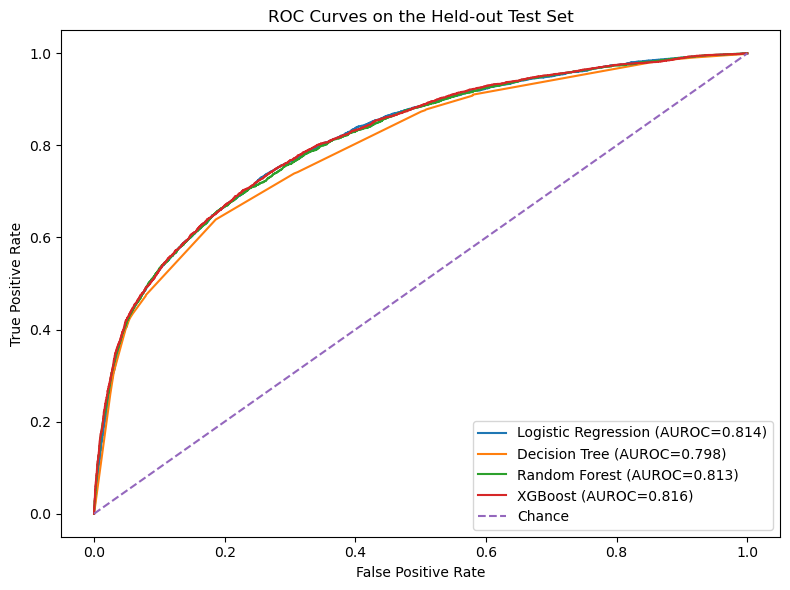

In [11]:
model_probabilities = {
    "Logistic Regression": (lr_probabilities, lr_metrics),
    "Decision Tree": (dt_probabilities, dt_metrics),
    "Random Forest": (rf_probabilities, rf_metrics),
    "XGBoost": (xgb_probabilities, xgb_metrics)
}

plt.figure(figsize=(8, 6))

for model_name, (probabilities, metrics) in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUROC={metrics['AUROC']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on the Held-out Test Set")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "four_model_roc_curves.png", dpi=200)
plt.show()


## 7. Precision–recall curves


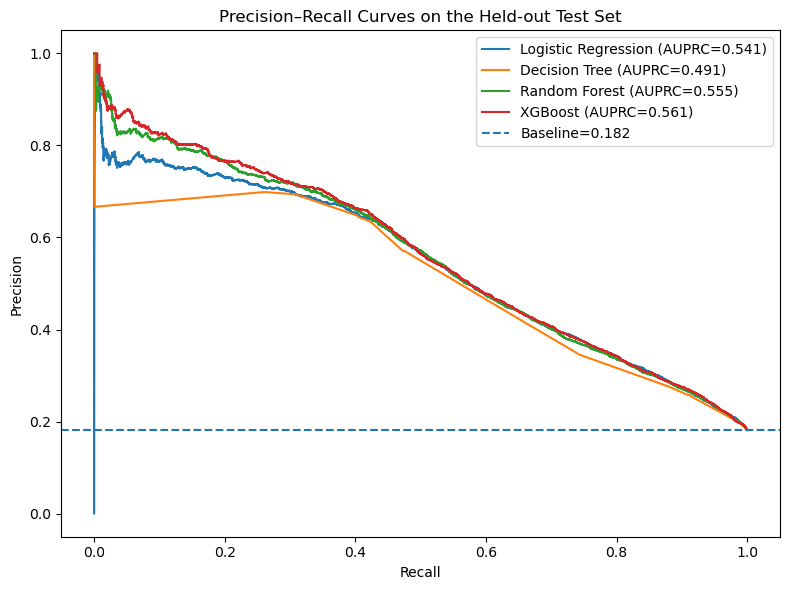

In [12]:
plt.figure(figsize=(8, 6))

for model_name, (probabilities, metrics) in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )
    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AUPRC={metrics['AUPRC']:.3f})"
    )

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves on the Held-out Test Set")
plt.legend()
plt.tight_layout()
plt.savefig(
    RESULTS / "four_model_precision_recall_curves.png",
    dpi=200
)
plt.show()


## 8. Confusion matrices


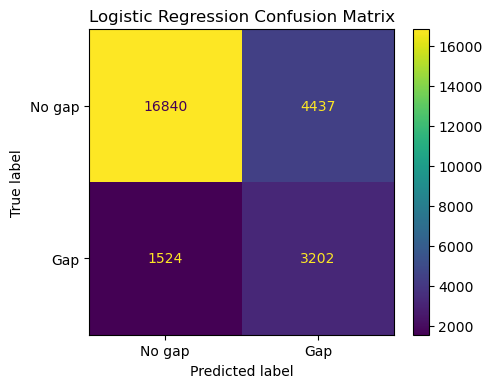

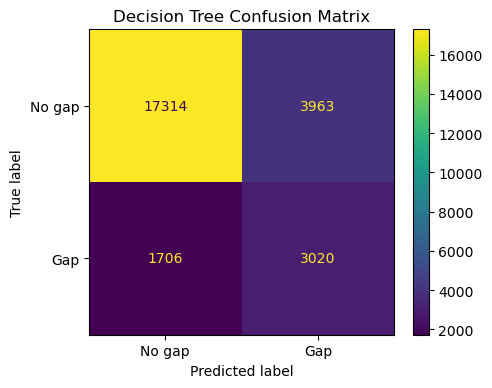

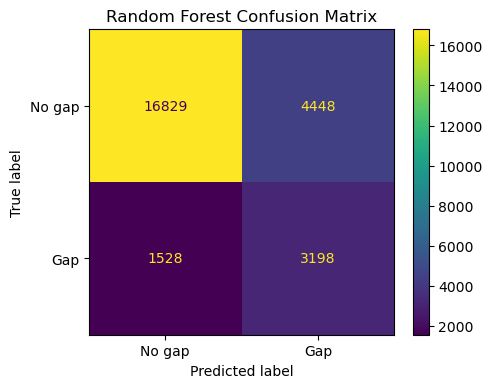

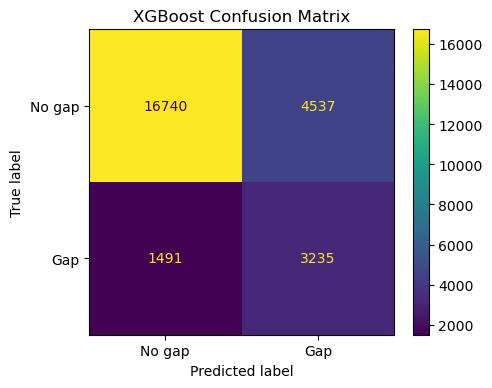

In [13]:
model_predictions = {
    "Logistic Regression": lr_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions
}

for model_name, predictions in model_predictions.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No gap", "Gap"],
        values_format="d",
        ax=ax
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    fig.tight_layout()

    safe_name = model_name.lower().replace(" ", "_")
    fig.savefig(
        RESULTS / f"{safe_name}_confusion_matrix.png",
        dpi=200
    )
    plt.show()


## 9. Logistic Regression coefficients


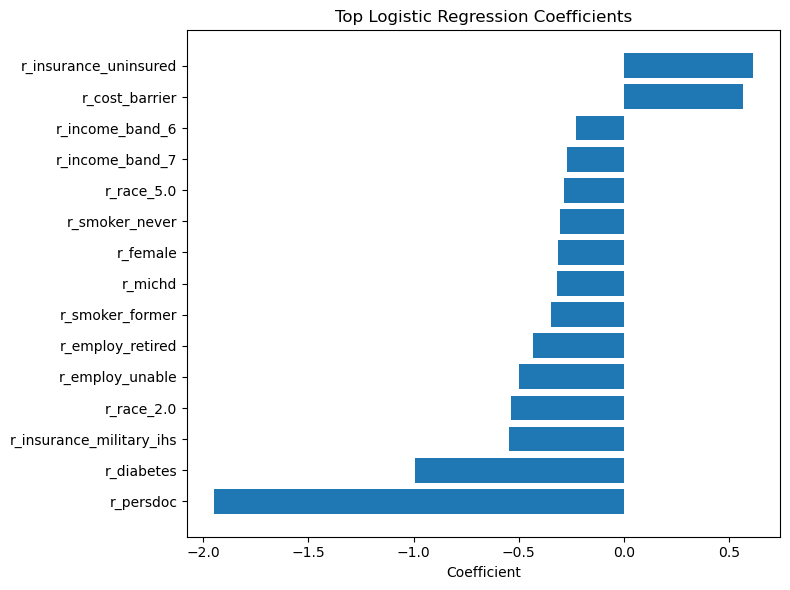

,Feature,Coefficient,Absolute coefficient
25,r_persdoc,-1.947311,1.947311
29,r_diabetes,-0.992772,0.992772
6,r_insurance_uninsured,0.613461,0.613461
26,r_cost_barrier,0.565208,0.565208
2,r_insurance_military_ihs,-0.544195,0.544195
9,r_race_2.0,-0.538883,0.538883
22,r_employ_unable,-0.497337,0.497337
21,r_employ_retired,-0.430740,0.430740
7,r_smoker_former,-0.348297,0.348297
30,r_michd,-0.319333,0.319333


In [14]:
lr_coefficients = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Coefficient": logistic_regression.coef_[0]
})

lr_coefficients["Absolute coefficient"] = (
    lr_coefficients["Coefficient"].abs()
)

lr_coefficients = lr_coefficients.sort_values(
    "Absolute coefficient",
    ascending=False
)

lr_coefficients.to_csv(
    RESULTS / "logistic_regression_coefficients.csv",
    index=False
)

lr_top = lr_coefficients.head(15).sort_values("Coefficient")

plt.figure(figsize=(8, 6))
plt.barh(lr_top["Feature"], lr_top["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig(
    RESULTS / "logistic_regression_coefficients.png",
    dpi=200
)
plt.show()

lr_coefficients.head(15)


## 10. Decision Tree feature importance


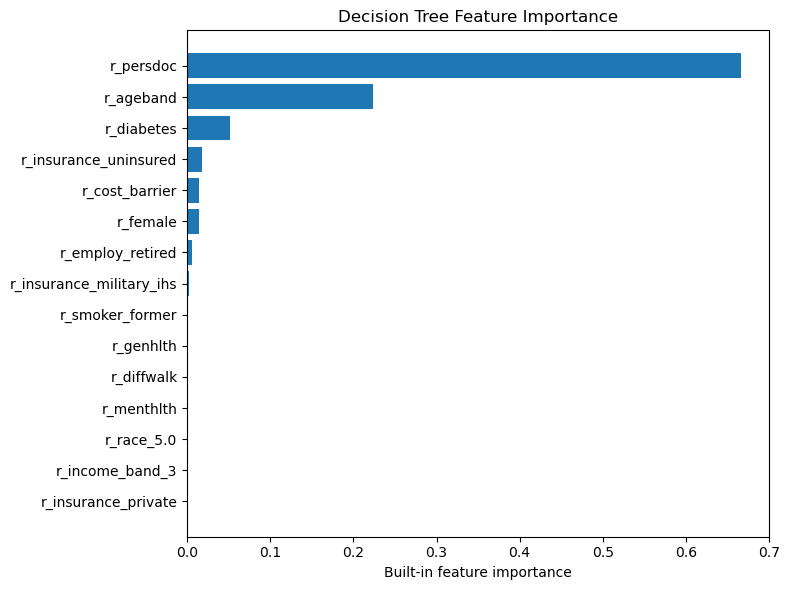

,Feature,Importance
25,r_persdoc,0.666810
36,r_ageband,0.223638
29,r_diabetes,0.051268
6,r_insurance_uninsured,0.017748
26,r_cost_barrier,0.014705
35,r_female,0.014361
21,r_employ_retired,0.005822
2,r_insurance_military_ihs,0.001815
7,r_smoker_former,0.000923
27,r_genhlth,0.000844


In [15]:
dt_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": decision_tree.feature_importances_
}).sort_values("Importance", ascending=False)

dt_importance.to_csv(
    RESULTS / "decision_tree_feature_importance.csv",
    index=False
)

dt_top = dt_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(dt_top["Feature"], dt_top["Importance"])
plt.xlabel("Built-in feature importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig(
    RESULTS / "decision_tree_feature_importance.png",
    dpi=200
)
plt.show()

dt_importance.head(15)


## 11. Random Forest feature importance


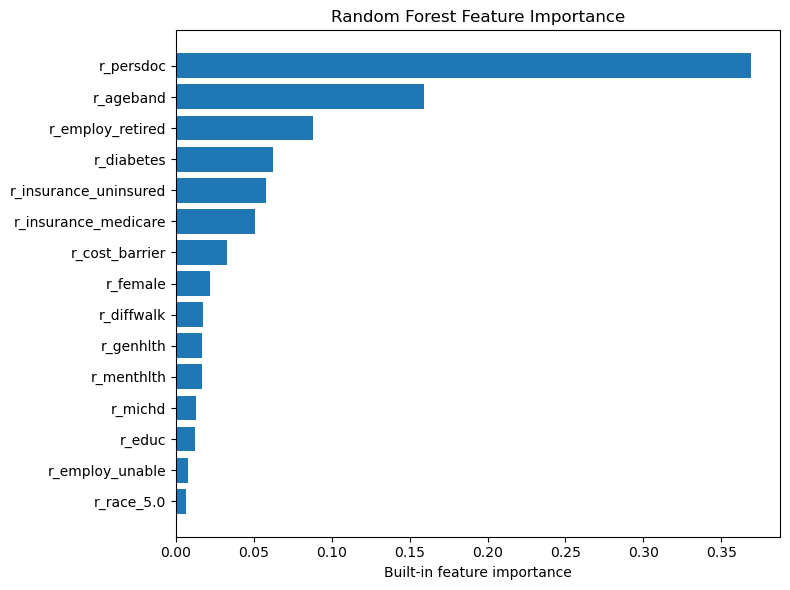

,Feature,Importance
25,r_persdoc,0.369283
36,r_ageband,0.158969
21,r_employ_retired,0.087666
29,r_diabetes,0.062429
6,r_insurance_uninsured,0.057964
1,r_insurance_medicare,0.050466
26,r_cost_barrier,0.032511
35,r_female,0.021723
31,r_diffwalk,0.017480
27,r_genhlth,0.016890


In [17]:
rf_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": random_forest.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance.to_csv(
    RESULTS / "random_forest_feature_importance.csv",
    index=False
)

rf_top = rf_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(rf_top["Feature"], rf_top["Importance"])
plt.xlabel("Built-in feature importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(
    RESULTS / "random_forest_feature_importance.png",
    dpi=200
)
plt.show()

rf_importance.head(15)


## 12. XGBoost feature importance


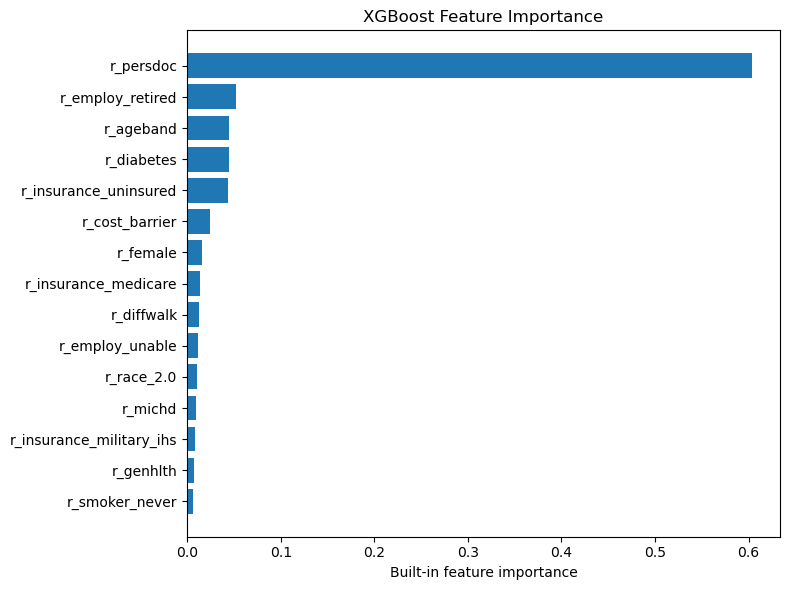

,Feature,Importance
25,r_persdoc,0.603429
21,r_employ_retired,0.052376
36,r_ageband,0.044700
29,r_diabetes,0.044476
6,r_insurance_uninsured,0.043989
26,r_cost_barrier,0.024718
35,r_female,0.015276
1,r_insurance_medicare,0.013302
31,r_diffwalk,0.012597
22,r_employ_unable,0.011534


In [18]:
xgb_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": xgboost_model.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_importance.to_csv(
    RESULTS / "xgboost_feature_importance.csv",
    index=False
)

xgb_top = xgb_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(xgb_top["Feature"], xgb_top["Importance"])
plt.xlabel("Built-in feature importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig(
    RESULTS / "xgboost_feature_importance.png",
    dpi=200
)
plt.show()

xgb_importance.head(15)


## Interpretation note

Because `r_no_checkup = 1` is less common than `r_no_checkup = 0`, accuracy should not be used alone.

- **Sensitivity** measures how many respondents with a preventive care gap are correctly identified.
- **Specificity** measures how many respondents without a care gap are correctly identified.
- **AUROC** measures overall class discrimination.
- **AUPRC** focuses more strongly on performance for the less common positive class.
- **Brier score** evaluates probability accuracy; lower values are better.

All four models use the same predictors, preprocessing, train-test split and test data, so their results are directly comparable.


## Summary

Among the four models, XGBoost achieved the best overall performance, with the highest AUROC (0.816) and AUPRC (0.561), indicating the strongest ability to distinguish respondents with preventive care gaps. Random Forest (AUROC = 0.813) and Logistic Regression (AUROC = 0.814) achieved comparable performance, while Decision Tree showed the lowest discrimination despite having the highest accuracy and specificity.

Model interpretation consistently identified having a personal doctor (r_persdoc), age group (r_ageband), and diabetes status (r_diabetes) as the most influential predictors across the tree-based models. Logistic Regression further indicated that being uninsured (r_insurance_uninsured) and reporting cost as a barrier to healthcare (r_cost_barrier) were associated with a higher likelihood of missing routine health check-ups, whereas having a personal doctor was associated with a lower likelihood.

TLDR: The results suggest that XGBoost is the preferred model for predictive performance, while Logistic Regression offers a strong and interpretable alternative with only a marginal reduction in performance. The findings also highlight the importance of healthcare access and continuity of care in predicting preventive healthcare utilisation.